<a href="https://colab.research.google.com/github/ashsiendo/DATA-201-Labs/blob/main/Assignments/Week2_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 2 Homework** - Ash Ibasan

EDA focus on the college, auto, and Boston datasets; includes data summaries, visualizations, and understanding relationships between variables.

***Note to self: Comments throughout are used as guides, mainly for Python syntax and reasons why certain steps are used.***

## Setup

*Import libraries necessary for answering homework questions. Datasets will be imported separately.*

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Q8 - College**

*The college dataset contains statistics for 777 US colleges and universities.*

## 8a)

Read the `College.csv` dataset into Python and view data

In [49]:
college = pd.read_csv("/content/drive/MyDrive/DATA 201 Fall 2026/Datasets/College.csv")
college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


## 8b)

Set the college names as the DataFrame's row index so they are not treated as a variable in the dataset (each row to be identified by its college name)

In [50]:
college2 = pd.read_csv("/content/drive/MyDrive/DATA 201 Fall 2026/Datasets/College.csv",
                       index_col=0) # index_col=0 uses first column (college names) as row index
college2.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [51]:
college3 = college.rename({"Unnamed: 0": "College"}, axis=1) # rename first column
college3 = college3.set_index("College") # set college names as row index
college3.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
College,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [52]:
college = college3 # keep modified version as main college DataFrame

## 8c)

Use `describe()` to produce a numerical summary of the variables in the college dataset

In [53]:
college.describe() # gives statistical overview of all quantitative variables

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


## 8d)

Create a scatterplot matrix comparing `Top10perc`, `Apps`, and `Enroll`

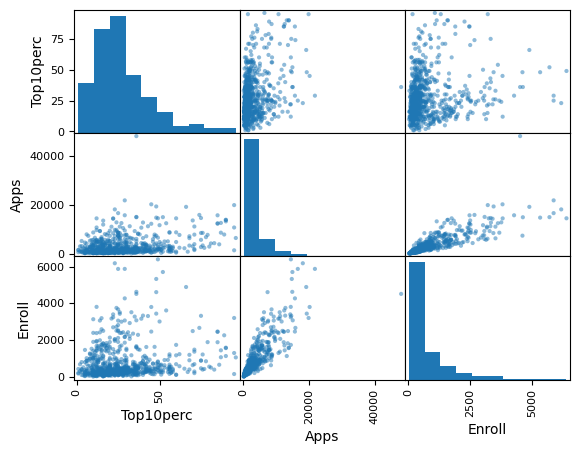

In [54]:
columns = ["Top10perc", "Apps", "Enroll"] # list allows multiple DataFrame columns to be selected at once

pd.plotting.scatter_matrix(college[columns])
plt.show()

## 8e)

Create side-by-side boxplots comparing `Outstate` tuition for private and public colleges

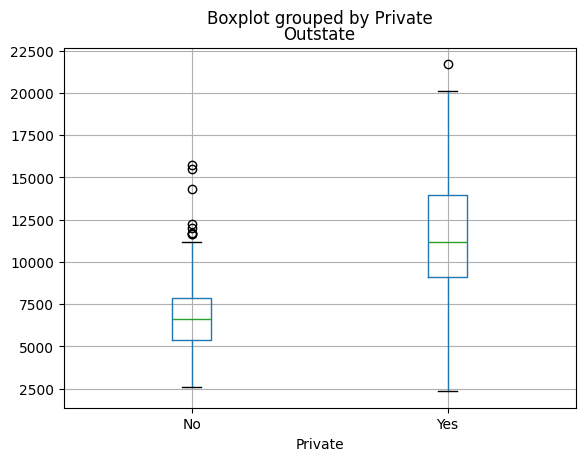

In [55]:
college.boxplot(column="Outstate", by="Private") # by= groups the numerical variable using categories in Private
plt.show()

## 8(f)

Create an `Elite` variable by grouping colleges based on whether more than 50% of their students come from the top 10% of their high school classes. Count the elite colleges, then compare `Outstate` tuition between elite and non-elite colleges using side-by-side boxplots

In [56]:
# Top10perc is stored as percentages (1-96), so use 0, 50, 100 instead of 0, 0.5, 1
# pd.cut() bins Top10perc into two groups based on 50% threshold
college["Elite"] = pd.cut(college["Top10perc"],
                          [0, 50, 100],
                          labels=["No", "Yes"])
college["Elite"].value_counts()

,count
Elite,
No,699
Yes,78


*78 colleges are classified as elite.*

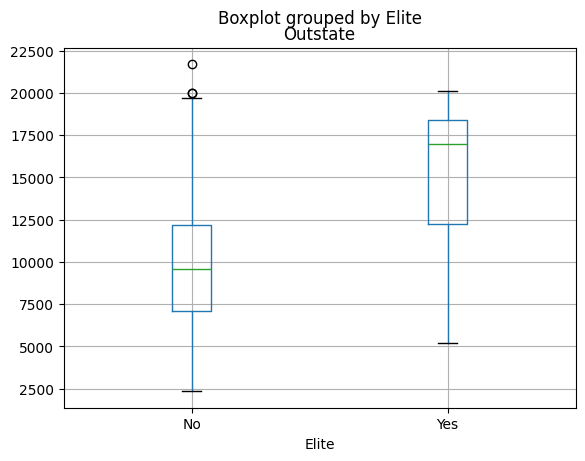

In [57]:
college.boxplot(column="Outstate", by="Elite")
plt.show()

## 8g)

Create histograms for several quantitative variables using different numbers of bins

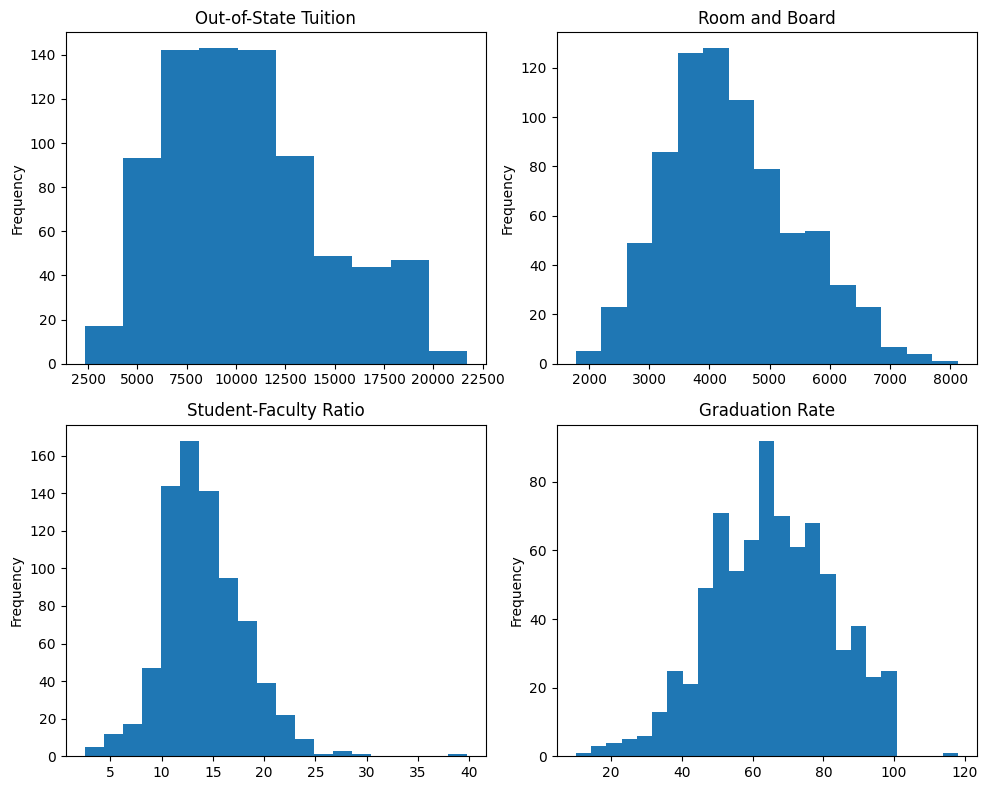

In [58]:
# creates 2x2 grid so four histograms can be displayed together
# figsize=(width, height) sets size of the entire figure (inches)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# ax=[row, column] chooses where each histogram goes in grid
college["Outstate"].plot.hist(bins=10, ax=axes[0, 0])
college["Room.Board"].plot.hist(bins=15, ax=axes[0, 1])
college["S.F.Ratio"].plot.hist(bins=20, ax=axes[1, 0])
college["Grad.Rate"].plot.hist(bins=25, ax=axes[1, 1])

axes[0, 0].set_title("Out-of-State Tuition")
axes[0, 1].set_title("Room and Board")
axes[1, 0].set_title("Student-Faculty Ratio")
axes[1, 1].set_title("Graduation Rate")

plt.tight_layout()
plt.show()

## 8h)

Continue dataset exploration and provide a brief summary of interesting findings

**1) Which college has a graduation rate of over 100%?**

In [59]:
college.loc[college["Grad.Rate"] > 100, "Grad.Rate"]

,Grad.Rate
College,
Cazenovia College,118


*Cazenovia College has a reported 118% graduation rate; above expected maximum of 100%*

**2) Which colleges have the highest out-of-state tuition?**

In [60]:
college["Outstate"].sort_values(ascending=False).head() # .sort_values(ascending=False) sorts values from largest to smallest

,Outstate
College,
Bennington College,21700
Massachusetts Institute of Technology,20100
Gettysburg College,19964
Reed College,19960
Princeton University,19900


*The five colleges with the highest out-of-state tuition are all private colleges.*

**3) Student-faculty ratio statistics**

In [67]:
college["S.F.Ratio"].describe()

,S.F.Ratio
count,777.000000
mean,14.089704
std,3.958349
min,2.500000
25%,11.500000
50%,13.600000
75%,16.500000
max,39.800000


*Student-faculty ratios have a median of 13.6 and an average of about 14.1. The middle 50% ranging from 11.5 to 16.5, though the overall range is much wider: from 2.5 to 39.8*

In [70]:
# highest s-f ratios
college["S.F.Ratio"].sort_values(ascending=False).head()

,S.F.Ratio
College,
Indiana Wesleyan University,39.8
Mesa State College,28.8
Lesley College,27.8
Goldey Beacom College,27.6
Saint Joseph's College,27.2


In [65]:
# lowest s-f ratios
college["S.F.Ratio"].sort_values().head()

,S.F.Ratio
College,
University of Charleston,2.5
Case Western Reserve University,2.9
Johns Hopkins University,3.3
Washington University,3.9
Wake Forest University,4.3


*Student-faculty ratios were sorted from highest to lowest and lowest to highest to see which colleges were at the extremes. Indiana Wesleyan University	was the upper extreme at 39.8, while the University of Charleston was the lower extreme at 2.5*